In [9]:
!pip install nbformat
!pip install --upgrade plotly

In [10]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

In [11]:
import plotly.io as pio
pio.renderers.default = "iframe"

In [12]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [13]:
tesla = yf.Ticker("TSLA")

In [14]:
tesla.history()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-09-02 00:00:00-04:00,328.230011,333.329987,325.600006,329.359985,58392000,0.0,0.0
2025-09-03 00:00:00-04:00,335.200012,343.329987,328.510010,334.089996,88733300,0.0,0.0
2025-09-04 00:00:00-04:00,336.149994,338.890015,331.480011,338.529999,60711000,0.0,0.0
2025-09-05 00:00:00-04:00,348.000000,355.869995,344.679993,350.839996,108989800,0.0,0.0
2025-09-08 00:00:00-04:00,354.640015,358.440002,344.839996,346.399994,75208300,0.0,0.0
2025-09-09 00:00:00-04:00,348.440002,350.769989,343.820007,346.970001,53816000,0.0,0.0
2025-09-10 00:00:00-04:00,350.549988,356.329987,346.070007,347.790009,72121700,0.0,0.0
2025-09-11 00:00:00-04:00,350.170013,368.989990,347.600006,368.809998,103756000,0.0,0.0
2025-09-12 00:00:00-04:00,370.940002,396.690002,370.239990,395.940002,168156400,0.0,0.0


In [15]:
tesla_data = tesla.history(period = "max")

In [16]:
tesla_data.reset_index(inplace = True)

In [17]:
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [18]:
url =" https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm" 

In [19]:
response = requests.get(url)

In [20]:
html_data = response.text

In [22]:
soup = BeautifulSoup(html_data, "html.parser")

In [23]:
soup


<!DOCTYPE html>

<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js"> <!--<![endif]-->
<head>
<meta charset="utf-8"/>
<meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/>
<link href="https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue" rel="canonical"/>
<title>Tesla Revenue 2010-2022 | TSLA | MacroTrends</title>
<meta content="Tesla annual/quarterly revenue history and growth rate from 2010 to 2022. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs and expenses are subtracted to arrive at net income.    
				
				&lt;ul style='margin-top:10px;'&gt;
				&lt;li&gt;Tesla revenue for the quarter ending September 30,

In [24]:
tables = pd.read_html(html_data)

In [25]:
tesla_revenue = tables[0]

In [26]:
tesla_revenue.columns

Index(['Tesla Annual Revenue (Millions of US $)', 'Tesla Annual Revenue (Millions of US $).1'], dtype='object')

In [27]:
tesla_revenue.rename(columns={
    'Tesla Annual Revenue (Millions of US $)': 'Date', 
    'Tesla Annual Revenue (Millions of US $).1': 'Revenue'
}, inplace=True)

In [28]:
tesla_revenue.head()

,Date,Revenue
0,2021,"$53,823"
1,2020,"$31,536"
2,2019,"$24,578"
3,2018,"$21,461"
4,2017,"$11,759"


In [29]:
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",|\$"," ",regex = True)

In [30]:
tesla_revenue.head()

,Date,Revenue
0,2021,53 823
1,2020,31 536
2,2019,24 578
3,2018,21 461
4,2017,11 759


In [31]:
tesla_revenue.dropna(inplace = True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [32]:
tesla_revenue.tail()

,Date,Revenue
8,2013,2 013
9,2012,413
10,2011,204
11,2010,117
12,2009,112


In [33]:
# Revenue sütunundaki boşlukları sil
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(" ", "")

# Sonra float'a çevir
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].astype(float)


In [34]:
tesla_revenue["Revenue"].astype(float).mean

<bound method Series.mean of 0     53823.0
1     31536.0
2     24578.0
3     21461.0
4     11759.0
5      7000.0
6      4046.0
7      3198.0
8      2013.0
9       413.0
10      204.0
11      117.0
12      112.0
Name: Revenue, dtype: float64>

In [35]:
tesla_revenue

,Date,Revenue
0,2021,53823.0
1,2020,31536.0
2,2019,24578.0
3,2018,21461.0
4,2017,11759.0
5,2016,7000.0
6,2015,4046.0
7,2014,3198.0
8,2013,2013.0
9,2012,413.0


In [36]:
##################

In [37]:
gamestop = yf.Ticker("GME")

In [38]:
gamestop.history()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-09-02 00:00:00-04:00,22.360001,23.410000,22.180000,23.410000,9567000,0.0,0.0
2025-09-03 00:00:00-04:00,23.510000,23.730000,22.680000,22.879999,9771400,0.0,0.0
2025-09-04 00:00:00-04:00,22.760000,22.850000,22.370001,22.370001,5531800,0.0,0.0
2025-09-05 00:00:00-04:00,22.600000,22.790001,22.280001,22.610001,11183300,0.0,0.0
2025-09-08 00:00:00-04:00,22.660000,23.469999,22.559999,23.219999,10151200,0.0,0.0
2025-09-09 00:00:00-04:00,23.100000,23.629999,22.940001,23.590000,18374400,0.0,0.0
2025-09-10 00:00:00-04:00,25.209999,25.430000,24.040001,24.370001,46254000,0.0,0.0
2025-09-11 00:00:00-04:00,24.000000,24.850000,23.889999,24.850000,12512600,0.0,0.0
2025-09-12 00:00:00-04:00,24.889999,25.139999,24.750000,24.930000,9320100,0.0,0.0


In [39]:
gme_data = gamestop.history(period = "max")

In [40]:
gme_data.reset_index(inplace = True)

In [41]:
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [59]:
gme_data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
5941,2025-09-24 00:00:00-04:00,26.830000,27.049999,26.219999,26.250000,5508800,0.0,0.0
5942,2025-09-25 00:00:00-04:00,25.930000,26.340000,25.270000,25.270000,8210500,0.0,0.0
5943,2025-09-26 00:00:00-04:00,25.530001,26.799999,25.440001,26.420000,8048300,0.0,0.0
5944,2025-09-29 00:00:00-04:00,27.200001,27.209999,26.790001,27.209999,7979000,0.0,0.0
5945,2025-09-30 00:00:00-04:00,27.209999,27.340000,26.799999,27.280001,5378300,0.0,0.0


In [42]:
link = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

In [43]:
response = requests.get(link)
html_data2 = response.text

In [44]:
soup = BeautifulSoup(html_data2, "html.parser")

In [45]:
soup

<!DOCTYPE html>

<!-- saved from url=(0105)https://web.archive.org/web/20200814131437/https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue -->
<html class="js flexbox canvas canvastext webgl no-touch geolocation postmessage websqldatabase indexeddb hashchange history draganddrop websockets rgba hsla multiplebgs backgroundsize borderimage borderradius boxshadow textshadow opacity cssanimations csscolumns cssgradients cssreflections csstransforms csstransforms3d csstransitions fontface generatedcontent video audio localstorage sessionstorage webworkers no-applicationcache svg inlinesvg smil svgclippaths" style=""><!--<![endif]--><head><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><script async="" src="./GameStop Revenue 2006-2020 _ GME _ MacroTrends_files/analytics.js.download" type="text/javascript"></script><script async="" src="./GameStop Revenue 2006-2020 _ GME _ MacroTrends_files/gpt.js.download" type="text/javascript"></script><script async="" src=".

In [46]:
html_data2 = pd.read_html(html_data2)

In [47]:
gme_revenue = tables[0]

In [48]:
gme_revenue.columns

Index(['Date', 'Revenue'], dtype='object')

In [49]:
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",|\$"," ",regex = True)

In [50]:
gme_revenue

,Date,Revenue
0,2021,53 823
1,2020,31 536
2,2019,24 578
3,2018,21 461
4,2017,11 759
5,2016,7 000
6,2015,4 046
7,2014,3 198
8,2013,2 013
9,2012,413


In [51]:
gme_revenue.dropna(inplace = True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

In [52]:
gme_revenue.tail()

,Date,Revenue
8,2013,2 013
9,2012,413
10,2011,204
11,2010,117
12,2009,112


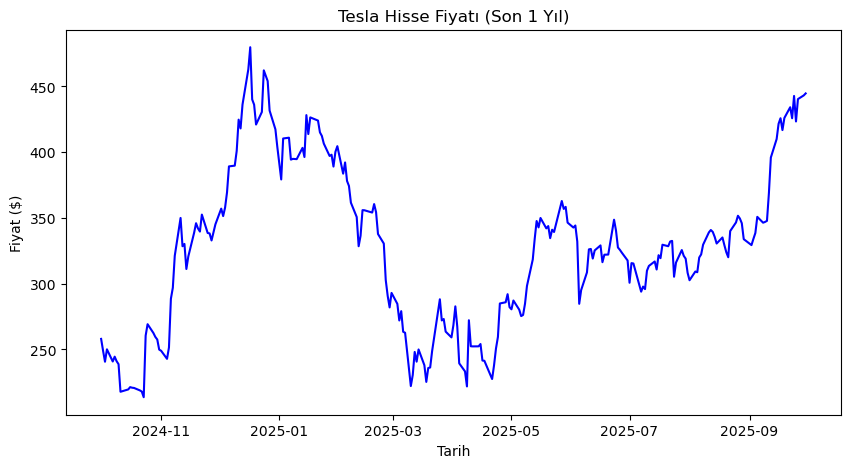

In [53]:
import matplotlib.pyplot as plt
import yfinance as yf

# Tesla verisini çekelim
tesla = yf.Ticker("TSLA")
tesla_stock = tesla.history(period="1y")

# Grafik çizelim
plt.figure(figsize=(10,5))
plt.plot(tesla_stock.index, tesla_stock["Close"], color="blue")
plt.title("Tesla Hisse Fiyatı (Son 1 Yıl)")
plt.xlabel("Tarih")
plt.ylabel("Fiyat ($)")
plt.show()


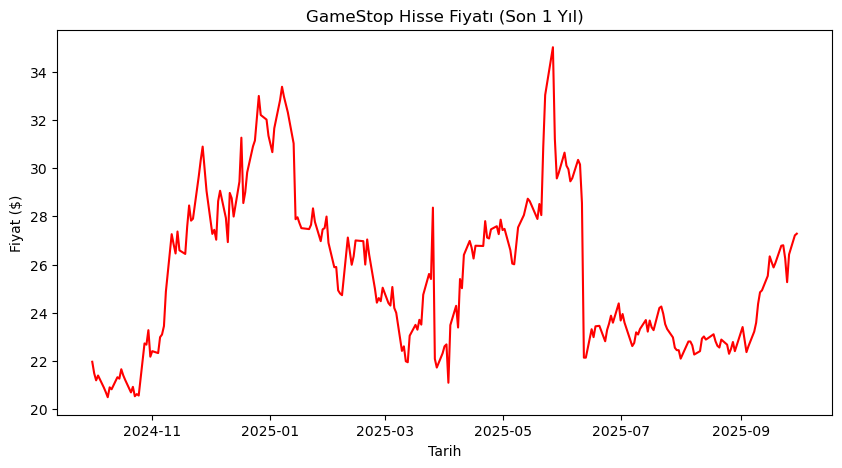

In [54]:
import matplotlib.pyplot as plt
import yfinance as yf

# GameStop verisini çekelim
gme = yf.Ticker("GME")
gme_stock = gme.history(period="1y")

# Grafik çizelim
plt.figure(figsize=(10,5))
plt.plot(gme_stock.index, gme_stock["Close"], color="red")
plt.title("GameStop Hisse Fiyatı (Son 1 Yıl)")
plt.xlabel("Tarih")
plt.ylabel("Fiyat ($)")
plt.show()
